# Day 2 / 7 — Regime Encoder: V-VSN + LSTM
### `src/models/vsn_lstm.py` — using your Day 1 settings

**Your Day 1 baseline (reused here):**
```python
window_size = 30
use_returns = use_volatility = use_momentum = use_volume_features = True
normalize_method = 'zscore'
n_assets = 10   # (this dataset only actually has 10 banking-sector stocks with usable completeness)
```
That gave you `x_t` windows of shape **(787, 30, 150)** — 787 usable samples, 30-day lookback, 150 engineered features (10 assets × 15 feature types).

**Today's model:** `VSNLSTM` — Variable Selection Network (feature gating) → LSTM (temporal memory) → `h_t`. This is the first half of the Differentiable Regime Encoder in your diagram (before the Temporal Attention block, which is Day 3).

**Why untrained architecture inspection isn't enough:** a freshly-initialized VSN's "selection weights" are close to random. To actually *see* what changing `vsn_hidden_dim`, `lstm_hidden_dim`, `lstm_num_layers`, and `dropout` does, we'll train a small **predictive probe**: feed `VSNLSTM`'s output into a single linear layer that predicts next-day average market return. This isn't your final RL objective (that's Day 7) — it's a fast proxy so the encoder actually learns *something*, and you can watch how each hyperparameter affects training speed, final loss, and which features get attended to.


## Step 0 — Setup (same zip as Day 1)

In [ ]:
from google.colab import files
import os

if not os.path.exists('/content/Regime detection portfolio.zip') and not os.path.exists('/content/project'):
    uploaded = files.upload()  # upload your project zip again if this is a fresh Colab session


In [ ]:
import os, zipfile, glob

ZIP_CANDIDATES = glob.glob('/content/*.zip')
PROJECT_DIR = '/content/project'

if not os.path.exists(PROJECT_DIR):
    assert ZIP_CANDIDATES, "No zip found in /content — upload it first."
    with zipfile.ZipFile(ZIP_CANDIDATES[0], 'r') as z:
        z.extractall(PROJECT_DIR)

ROOT = None
for dirpath, _, filenames in os.walk(PROJECT_DIR):
    if 'main.py' in filenames:
        ROOT = dirpath
        break
assert ROOT is not None
print("Project root:", ROOT)


Project root: /content/project/Regime detection portfolio


In [ ]:
!pip install -q torch pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import sys
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from src.config.config import get_config, DATA_RAW_DIR
from src.data.data_loader import CSEDataLoader
from src.data.preprocessor import Preprocessor
from src.models.vsn_lstm import VSNLSTM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Device: cuda


## Step 1 — Rebuild `x_t` windows using your Day 1 config

In [ ]:
DAY1 = dict(window_size=30, normalize_method='zscore', n_assets=10)

loader = CSEDataLoader(raw_data_dir=DATA_RAW_DIR)
prices, volumes = loader.load_prices_and_volumes(n_assets=DAY1['n_assets'])
print("Prices shape:", prices.shape)

preprocessor = Preprocessor(window_size=DAY1['window_size'], normalize_method=DAY1['normalize_method'])
features = preprocessor.engineer_features(prices, volumes)
normalized = preprocessor.fit_normalize(features)
windows = preprocessor.create_windows(normalized.values)
feature_names = list(features.columns)

print("Windows shape:", windows.shape, "| n_features:", len(feature_names))


Prices shape: (836, 10)
Windows shape: (787, 30, 150) | n_features: 150


## Step 2 — Build a next-day-return target and align it with each window

This is *only* for the training probe below (predicting next-day average market return) — not part of your PPO reward. It gives the encoder a real signal to learn from so we can observe hyperparameter effects.


In [ ]:
# Average log return across the 10 assets, shifted so target[d] = return realized the day AFTER d
avg_log_return = np.log(prices / prices.shift(1)).mean(axis=1)
target_next = avg_log_return.shift(-1)

# Each window's "label date" is the last day inside that window
window_dates = features.index[DAY1['window_size'] - 1:]
targets = target_next.reindex(window_dates)

valid_mask = targets.notna().values
windows_valid = windows[valid_mask]
targets_valid = targets.values[valid_mask].astype(np.float32)

print("Valid windows:", windows_valid.shape, "| targets:", targets_valid.shape)

# Chronological train/val split (80/20) — no shuffling, this is a time series
n = windows_valid.shape[0]
n_train = int(n * 0.8)
X_train, X_val = windows_valid[:n_train], windows_valid[n_train:]
y_train, y_val = targets_valid[:n_train], targets_valid[n_train:]
print(f"Train: {X_train.shape[0]} windows | Val: {X_val.shape[0]} windows")


Valid windows: (786, 30, 150) | targets: (786,)
Train: 628 windows | Val: 158 windows


## Step 3 — Training probe helper

`VSNLSTM` output at the last timestep → `Linear(lstm_hidden_dim, 1)` → predicted next-day return. Trained with MSE. We track train/val loss per epoch, final loss, parameter count, and the average variable-selection weight per feature (to see which of the 150 features the VSN leans on).


In [ ]:
def train_probe(vsn_hidden_dim=64, lstm_hidden_dim=128, lstm_num_layers=2, dropout=0.1,
                epochs=30, lr=1e-3, batch_size=32, seed=42, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    n_features = X_train.shape[2]
    encoder = VSNLSTM(
        n_features=n_features,
        vsn_hidden_dim=vsn_hidden_dim,
        lstm_hidden_dim=lstm_hidden_dim,
        lstm_num_layers=lstm_num_layers,
        dropout=dropout,
    ).to(device)
    head = nn.Linear(lstm_hidden_dim, 1).to(device)

    params = list(encoder.parameters()) + list(head.parameters())
    n_params = sum(p.numel() for p in params)
    optimizer = torch.optim.Adam(params, lr=lr)
    loss_fn = nn.MSELoss()

    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.FloatTensor(y_val).to(device)

    n_train_samples = X_train_t.shape[0]
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        encoder.train(); head.train()
        perm = torch.randperm(n_train_samples)
        epoch_loss = 0.0
        for i in range(0, n_train_samples, batch_size):
            idx = perm[i:i+batch_size]
            xb = X_train_t[idx].to(device)
            yb = y_train_t[idx].to(device)

            out, var_weights, _ = encoder(xb)
            pred = head(out[:, -1, :]).squeeze(-1)
            loss = loss_fn(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.shape[0]

        train_losses.append(epoch_loss / n_train_samples)

        encoder.eval(); head.eval()
        with torch.no_grad():
            out, val_var_weights, _ = encoder(X_val_t)
            pred_val = head(out[:, -1, :]).squeeze(-1)
            val_losses.append(loss_fn(pred_val, y_val_t).item())

        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:3d} | train MSE {train_losses[-1]:.6f} | val MSE {val_losses[-1]:.6f}")

    # Mean variable-selection weight per feature, averaged over val set + time
    mean_var_weights = val_var_weights.mean(dim=(0, 1)).detach().cpu().numpy()

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_val_loss': val_losses[-1],
        'n_params': n_params,
        'mean_var_weights': mean_var_weights,
    }

print("train_probe() ready.")


train_probe() ready.


## Step 4 — Baseline run (config defaults: `vsn_hidden_dim=64`, `lstm_hidden_dim=128`, `lstm_num_layers=2`, `dropout=0.1`)

  epoch   0 | train MSE 0.009042 | val MSE 0.000779
  epoch   5 | train MSE 0.000590 | val MSE 0.000213
  epoch  10 | train MSE 0.000330 | val MSE 0.000275
  epoch  15 | train MSE 0.000165 | val MSE 0.000336
  epoch  20 | train MSE 0.000085 | val MSE 0.000326
  epoch  25 | train MSE 0.000068 | val MSE 0.000374
  epoch  29 | train MSE 0.000050 | val MSE 0.000375


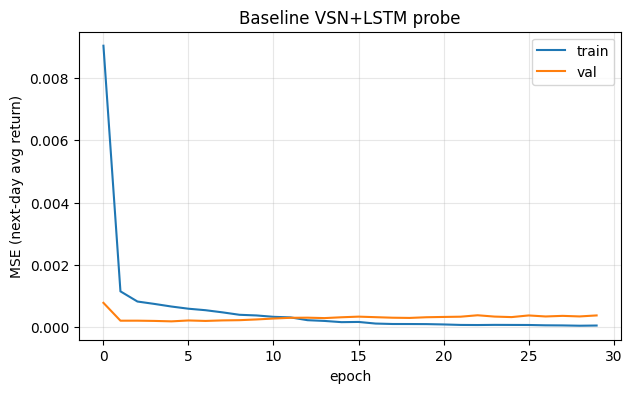

Params: 1,504,445 | Final val MSE: 0.000375


In [ ]:
baseline = train_probe(vsn_hidden_dim=64, lstm_hidden_dim=32, lstm_num_layers=2, dropout=0.1,
                        epochs=30, verbose=True)

plt.figure(figsize=(7,4))
plt.plot(baseline['train_losses'], label='train')
plt.plot(baseline['val_losses'], label='val')
plt.xlabel('epoch'); plt.ylabel('MSE (next-day avg return)')
plt.title('Baseline VSN+LSTM probe'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"Params: {baseline['n_params']:,} | Final val MSE: {baseline['final_val_loss']:.6f}")


In [ ]:
# Which features does the VSN attend to most, on average, at baseline?
top_idx = np.argsort(baseline['mean_var_weights'])[::-1][:15]
top_features = pd.DataFrame({
    'feature': [feature_names[i] for i in top_idx],
    'mean_weight': baseline['mean_var_weights'][top_idx]
})
top_features


,feature,mean_weight
0,NTB_vol_ratio_20d,0.025033
1,NTB_macd_hist,0.021764
2,UBC_vol_ratio_20d,0.021685
3,PABC_macd,0.021539
4,SEYB_vol_ratio_20d,0.017859
5,UBC_macd_signal,0.016845
6,NTB_macd_signal,0.016160
7,NTB_macd,0.015461
8,PABC_macd_signal,0.015450
9,ABL_vol_ratio_10d,0.013833


**Your task:** do the top-weighted features make intuitive sense (e.g. returns/volatility of specific banking stocks, or momentum indicators)? Note anything surprising.

> Your answer:


## Experiment A — `vsn_hidden_dim`

Controls the capacity of the per-timestep feature-selection embedding, independent of the LSTM. Try **16, 32, 64 (baseline), 128**.


vsn_hidden_dim=16
vsn_hidden_dim=32
vsn_hidden_dim=64
vsn_hidden_dim=128


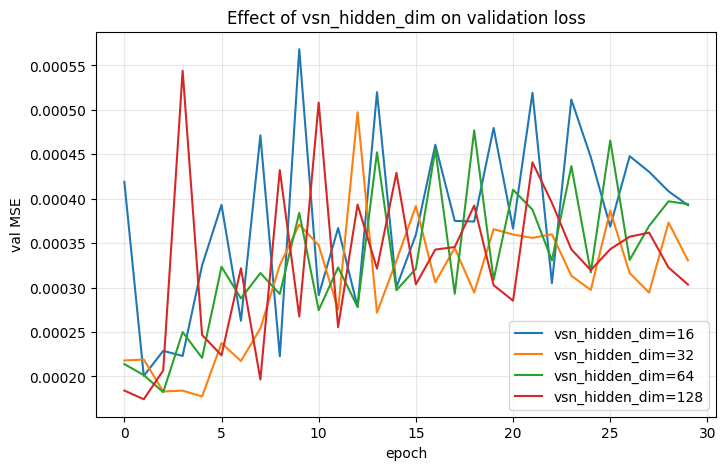

,vsn_hidden_dim,final_val_mse,n_params
0,16,0.000393,611405
1,32,0.000330,984413
2,64,0.000394,1730429
3,128,0.000303,3222461


In [ ]:
vsn_dims = [16, 32, 64, 128]
vsn_results = {}
for d in vsn_dims:
    print(f"vsn_hidden_dim={d}")
    vsn_results[d] = train_probe(vsn_hidden_dim=d, lstm_hidden_dim=128, lstm_num_layers=2, dropout=0.1, epochs=30)

plt.figure(figsize=(8,5))
for d, res in vsn_results.items():
    plt.plot(res['val_losses'], label=f'vsn_hidden_dim={d}')
plt.xlabel('epoch'); plt.ylabel('val MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Effect of vsn_hidden_dim on validation loss')
plt.show()

pd.DataFrame([{'vsn_hidden_dim': d, 'final_val_mse': r['final_val_loss'], 'n_params': r['n_params']} for d, r in vsn_results.items()])


**Your task:** does a bigger VSN actually reduce validation MSE on this small dataset, or does it start overfitting (train loss keeps dropping, val loss flattens/rises)? What does that tell you about how much capacity 150 input features and ~630 training windows can support?

> Your answer:


## Experiment B — `lstm_hidden_dim`

Controls the size of `h_temp`, the latent market-state vector passed on to the Actor/Critic. Try **32, 64, 128 (baseline), 256**.


lstm_hidden_dim=32
lstm_hidden_dim=64
lstm_hidden_dim=128
lstm_hidden_dim=256


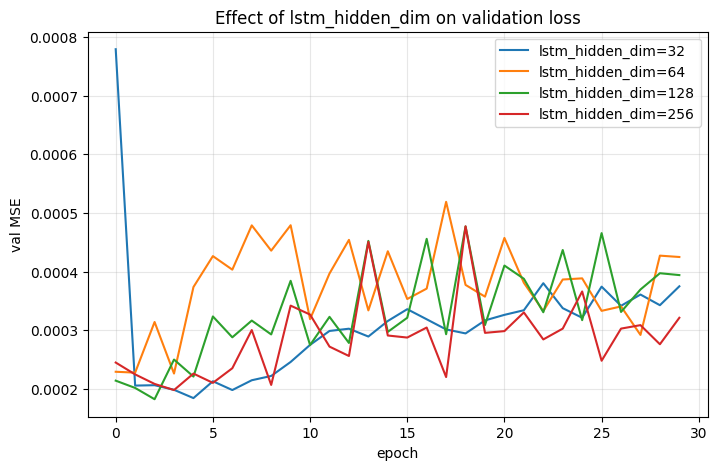

,lstm_hidden_dim,final_val_mse,n_params
0,32,0.000375,1504445
1,64,0.000425,1553149
2,128,0.000394,1730429
3,256,0.000321,2404477


In [ ]:
lstm_dims = [32, 64, 128, 256]
lstm_dim_results = {}
for d in lstm_dims:
    print(f"lstm_hidden_dim={d}")
    lstm_dim_results[d] = train_probe(vsn_hidden_dim=64, lstm_hidden_dim=d, lstm_num_layers=2, dropout=0.1, epochs=30)

plt.figure(figsize=(8,5))
for d, res in lstm_dim_results.items():
    plt.plot(res['val_losses'], label=f'lstm_hidden_dim={d}')
plt.xlabel('epoch'); plt.ylabel('val MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Effect of lstm_hidden_dim on validation loss')
plt.show()

pd.DataFrame([{'lstm_hidden_dim': d, 'final_val_mse': r['final_val_loss'], 'n_params': r['n_params']} for d, r in lstm_dim_results.items()])


**Your task:** `lstm_hidden_dim` also becomes the input size to Temporal Attention (Day 3) and part of `latent_state_dim` downstream. Is there a dimension here that gives clearly diminishing returns? That's a candidate for your final config — bigger isn't always better once the Actor/Critic have to consume it too.

> Your answer:


## Experiment C — `lstm_num_layers`

Deeper LSTMs can model more complex temporal dynamics but are more prone to overfitting on ~630 training samples. Try **1, 2 (baseline), 3**.


lstm_num_layers=1
lstm_num_layers=2
lstm_num_layers=3


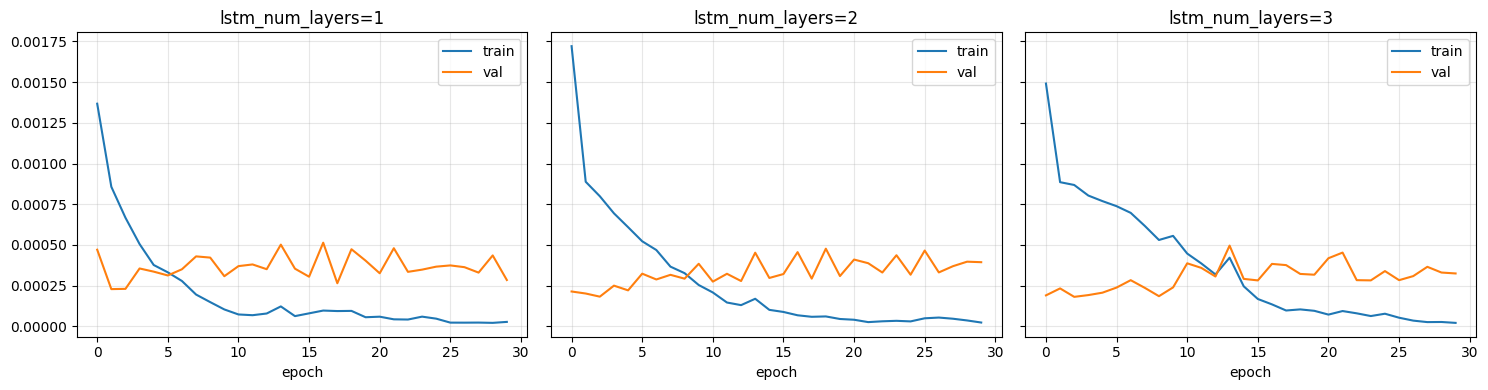

In [ ]:
layer_counts = [1, 2, 3]
layer_results = {}
for n_layers in layer_counts:
    print(f"lstm_num_layers={n_layers}")
    layer_results[n_layers] = train_probe(vsn_hidden_dim=64, lstm_hidden_dim=128, lstm_num_layers=n_layers, dropout=0.1, epochs=30)

fig, axes = plt.subplots(1, len(layer_counts), figsize=(5*len(layer_counts), 4), sharey=True)
for ax, n_layers in zip(axes, layer_counts):
    res = layer_results[n_layers]
    ax.plot(res['train_losses'], label='train')
    ax.plot(res['val_losses'], label='val')
    ax.set_title(f'lstm_num_layers={n_layers}')
    ax.set_xlabel('epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Your task:** look at the train/val gap in each panel — does adding layers widen the gap (a sign of overfitting on this dataset size) faster than it improves val loss?

> Your answer:


## Experiment D — `dropout`

Regularization on the LSTM (and inside the VSN's GRN). Try **0.0, 0.1 (baseline), 0.3, 0.5**.


dropout=0.0
dropout=0.1
dropout=0.3
dropout=0.5


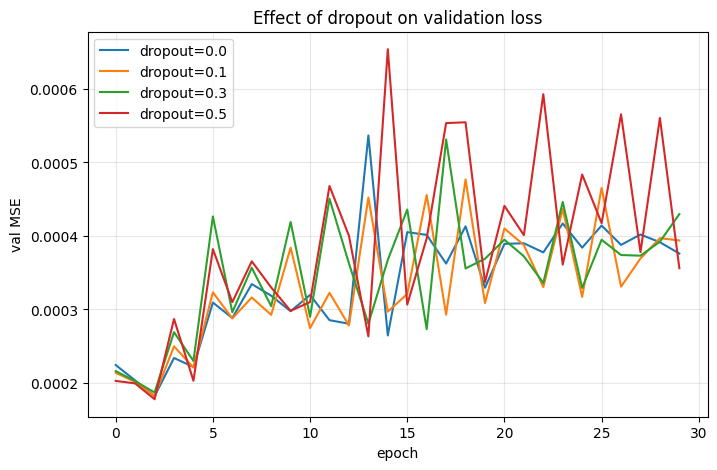

,dropout,final_val_mse
0,0.0,0.000376
1,0.1,0.000394
2,0.3,0.000430
3,0.5,0.000356


In [ ]:
dropout_vals = [0.0, 0.1, 0.3, 0.5]
dropout_results = {}
for p in dropout_vals:
    print(f"dropout={p}")
    dropout_results[p] = train_probe(vsn_hidden_dim=64, lstm_hidden_dim=128, lstm_num_layers=2, dropout=p, epochs=30)

plt.figure(figsize=(8,5))
for p, res in dropout_results.items():
    plt.plot(res['val_losses'], label=f'dropout={p}')
plt.xlabel('epoch'); plt.ylabel('val MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Effect of dropout on validation loss')
plt.show()

pd.DataFrame([{'dropout': p, 'final_val_mse': r['final_val_loss']} for p, r in dropout_results.items()])


**Your task:** with `lstm_num_layers=2` (where dropout actually applies between LSTM layers, per PyTorch's `nn.LSTM` — note it does *nothing* if `num_layers=1`), does higher dropout help validation loss, or is the model already small enough that regularization mostly just slows learning?

> Your answer:


## Wrap-up

Log your Day 2 choices below — you'll carry `lstm_hidden_dim` forward into Day 3, since it must match `mha_dim` in the Temporal Attention block (`config.regime_encoder.mha_dim`, which your config asserts equals `lstm_hidden_dim`).


In [ ]:
day2_choices = {
    'vsn_hidden_dim': None,      # e.g. 64
    'lstm_hidden_dim': None,     # e.g. 128 -- must match mha_dim on Day 3
    'lstm_num_layers': None,     # e.g. 2
    'dropout': None,             # e.g. 0.1
}
import json
print(json.dumps(day2_choices, indent=2))
with open('/content/day2_choices.json', 'w') as f:
    json.dump(day2_choices, f, indent=2)


{
  "vsn_hidden_dim": null,
  "lstm_hidden_dim": null,
  "lstm_num_layers": null,
  "dropout": null
}


**Next up — Day 3:** Temporal Attention (Multi-Head Attention) in `src/models/temporal_attention.py`. You'll take the LSTM output sequence from today's encoder and see how `mha_num_heads` reshapes attention over the 30-day window — including a visualization of which past days the model attends to most when forming `h_temp`.
